# RQ2: Effects on Test Suite Size and Runtime

**Research Question**: To which degree does generalization affect the size and runtime of the target test suites?

This notebook analyzes the secondary effects of test generalization across four key areas:
- **Test Count**: Number of tests added, removed, and total change
- **Lines of Code**: LOC changes in test suites after generalization  
- **Runtime**: Test execution time changes and property-based test overhead
- **Test Filtering**: Impact of filtering non-contributing tests on generalization outcomes

In [1]:
from teralizer.config import db_config
from teralizer.rq2_test_suite_effects import (
    get_test_count_changes_by_project_variant,
    get_line_count_changes_by_project_variant,
    get_runtime_changes_by_project_variant,
    get_test_vs_generalization_runtime_comparison,
    get_test_filtering_impact_data,
    compute_test_suite_change_statistics,
    compute_line_count_change_statistics,
    compute_runtime_change_statistics,
    compute_test_vs_generalization_runtime_statistics,
    compute_test_filtering_statistics,
    generate_tests_per_project_table,
    generate_tests_per_project_csv,
    generate_lines_per_project_table,
    generate_lines_per_project_csv,
    generate_runtime_per_project_table,
    generate_runtime_per_project_csv,
    generate_test_runtime_differences_csv,
    generate_test_filtering_breakdown_csv,
    generate_test_filtering_summary_csv,
)
from teralizer.exports import save_latex_table, save_csv_data, save_figure
from teralizer.plotting import setup_paper_style
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

# Database connection
conn = db_config.get_dev_engine()

# Configure paper style
setup_paper_style()

## Number of Tests in Test Suite

Analysis of how many tests are added and removed during generalization, and the net effect on test suite size.

In [2]:
# Get test count changes for NAIVE_200_TRIES and IMPROVED_200_TRIES variants
test_count_data = get_test_count_changes_by_project_variant(conn)
test_count_stats = compute_test_suite_change_statistics(test_count_data)

# Generate LaTeX table and CSV data
tests_table = generate_tests_per_project_table(test_count_stats)
tests_csv = generate_tests_per_project_csv(test_count_stats)

# Save outputs
save_latex_table(tests_table, "tab-tests-per-project")
save_csv_data(tests_csv, "tests-per-project-data")

print(
    f"Generated test count analysis for {len(test_count_stats)} project-variant combinations"
)
display(
    test_count_stats[
        [
            "project_name",
            "b_variant",
            "tests_before",
            "added_tests",
            "removed_tests",
            "tests_after",
            "tests_delta",
        ]
    ].head()
)

Saved LaTeX table to /app/analysis/output/verify/tables/tab-tests-per-project.tex
Generated test count analysis for 14 project-variant combinations


,project_name,b_variant,tests_before,added_tests,removed_tests,tests_after,tests_delta
8,eqbench-es-default-1s,NAIVE_200_TRIES,4718,177,177,4718,0
9,eqbench-es-default-1s,IMPROVED_200_TRIES,4718,206,206,4718,0
10,eqbench-es-default-10s,NAIVE_200_TRIES,4875,174,173,4876,1
11,eqbench-es-default-10s,IMPROVED_200_TRIES,4875,211,210,4876,1
6,eqbench-es-default-60s,NAIVE_200_TRIES,4974,174,174,4974,0


## Lines of Code in Test Suite

Analysis of how test generalization affects the total lines of code in test suites.

In [3]:
# Get line count changes for generalized variants
line_count_data = get_line_count_changes_by_project_variant(conn)
line_count_stats = compute_line_count_change_statistics(line_count_data)

# Generate LaTeX table and CSV data
lines_table = generate_lines_per_project_table(line_count_stats)
lines_csv = generate_lines_per_project_csv(line_count_stats)

# Save outputs
save_latex_table(lines_table, "tab-lines-per-project")
save_csv_data(lines_csv, "lines-per-project-data")

print(
    f"Generated line count analysis for {len(line_count_stats)} project-variant combinations"
)
display(
    line_count_stats[
        [
            "project_name",
            "b_variant",
            "lines_before",
            "added_lines",
            "removed_lines",
            "lines_after",
            "lines_delta",
        ]
    ].head()
)

Saved LaTeX table to /app/analysis/output/verify/tables/tab-lines-per-project.tex
Generated line count analysis for 14 project-variant combinations


,project_name,b_variant,lines_before,added_lines,removed_lines,lines_after,lines_delta
8,eqbench-es-default-1s,NAIVE_200_TRIES,30989,11780,1127,41642,10653
9,eqbench-es-default-1s,IMPROVED_200_TRIES,30989,19019,1302,48706,17717
10,eqbench-es-default-10s,NAIVE_200_TRIES,32503,11520,1061,42962,10459
11,eqbench-es-default-10s,IMPROVED_200_TRIES,32503,20353,1284,51572,19069
6,eqbench-es-default-60s,NAIVE_200_TRIES,33510,11623,1069,44064,10554


## Test Suite Execution Time

Analysis of how generalization affects test execution time, including runtime overhead and changes in total execution time.

In [4]:
# Get runtime changes for generalized variants
runtime_data = get_runtime_changes_by_project_variant(conn)
runtime_stats = compute_runtime_change_statistics(runtime_data)

# Generate LaTeX table and CSV data
runtime_table = generate_runtime_per_project_table(runtime_stats)
runtime_csv = generate_runtime_per_project_csv(runtime_stats)

# Save outputs
save_latex_table(runtime_table, "tab-runtime-per-project")
save_csv_data(runtime_csv, "runtime-per-project-data")

print(
    f"Generated runtime analysis for {len(runtime_stats)} project-variant combinations"
)
display(
    runtime_stats[
        [
            "project_name",
            "b_variant",
            "runtime_before",
            "added_runtime",
            "removed_runtime",
            "runtime_after",
            "runtime_delta",
        ]
    ].head()
)

Saved LaTeX table to /app/analysis/output/verify/tables/tab-runtime-per-project.tex
Generated runtime analysis for 14 project-variant combinations


,project_name,b_variant,runtime_before,added_runtime,removed_runtime,runtime_after,runtime_delta
8,eqbench-es-default-1s,NAIVE_200_TRIES,17.442322,100.94299,0.737999,117.647316,100.204994
9,eqbench-es-default-1s,IMPROVED_200_TRIES,17.442322,101.62001,0.677999,118.384330,100.942010
10,eqbench-es-default-10s,NAIVE_200_TRIES,16.697403,106.19200,0.658999,122.230410,105.533005
11,eqbench-es-default-10s,IMPROVED_200_TRIES,16.697403,139.64195,0.564999,155.774350,139.076950
6,eqbench-es-default-60s,NAIVE_200_TRIES,18.207197,221.06607,0.756999,238.516270,220.309070


## Property-Based Test Execution Overhead

Analysis of how much longer property-based jqwik tests take to execute compared to original JUnit tests, showing the inherent overhead of property-based testing.

In [5]:
# Get comparison between original JUnit tests and property-based jqwik tests
runtime_comparison_data = get_test_vs_generalization_runtime_comparison(conn)
runtime_comparison_stats = compute_test_vs_generalization_runtime_statistics(
    runtime_comparison_data
)

# Generate CSV data for the comparison
runtime_comparison_csv = generate_test_runtime_differences_csv(runtime_comparison_stats)
save_csv_data(runtime_comparison_csv, "test-runtime-differences-figure-data")

print(f"Generated runtime comparison for {len(runtime_comparison_stats)} variants")
display(
    runtime_comparison_stats[
        [
            "variant",
            "mean_t_runtime_ms",
            "mean_g_runtime_ms",
            "mean_runtime_diff_ms",
            "mean_runtime_diff_per_try_ms",
        ]
    ].head()
)

Generated runtime comparison for 7 variants


,variant,mean_t_runtime_ms,mean_g_runtime_ms,mean_runtime_diff_ms,mean_runtime_diff_per_try_ms
0,BASELINE,4.282540,153.843637,149.561096,149.561096
1,NAIVE_10_TRIES,4.526110,290.657544,286.131434,28.613143
2,NAIVE_50_TRIES,4.514151,353.077680,348.563530,6.971271
3,NAIVE_200_TRIES,4.535978,1140.741927,1136.205949,5.681030
4,IMPROVED_10_TRIES,4.531049,193.700288,189.169239,18.916924


Saved figure to /app/analysis/output/verify/figures/fig_test_runtime_differences.pdf


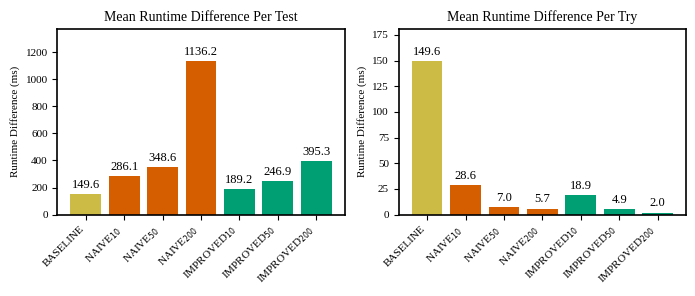

In [6]:
# Create property-based test overhead visualization
from teralizer.plotting import (
    get_wong_variant_colors,
    get_variant_color,
    get_font_size,
    calculate_label_offset,
    FIGURE_CONFIG,
)
import re

wong_colors = get_wong_variant_colors()


def format_variant_label(label):
    """Format variant labels for display."""
    match = re.match(r"([A-Z]+)_([0-9]+)_TRIES", label)
    if match:
        name, number = match.groups()
        return f"{name}$_{{{number}}}$"
    else:
        return label


fig_width = FIGURE_CONFIG["width_comparison"]
fig_height = FIGURE_CONFIG["comparison_height"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(fig_width, fig_height))

# Extract data for plotting
variants = runtime_comparison_stats["variant"].tolist()
mean_diff = runtime_comparison_stats["mean_runtime_diff_ms"].tolist()
mean_diff_per_try = runtime_comparison_stats["mean_runtime_diff_per_try_ms"].tolist()
x_positions = np.arange(len(variants))

# Choose colors using variant-based colors
bar_colors = [get_variant_color(v) for v in variants]

# Plot 1: Mean Runtime Difference (property-based vs original JUnit tests)
bars1 = ax1.bar(x_positions, mean_diff, color=bar_colors)

# Add data labels with percentage-based offset
y1_min, y1_max = ax1.get_ylim()
offset1 = calculate_label_offset(y1_min, y1_max, FIGURE_CONFIG["label_offset_pct"])
for bar in bars1:
    height = bar.get_height()
    if height >= 0:
        va = "bottom"
        offset = offset1
    else:
        va = "top"
        offset = -offset1
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + offset,
        f"{height:.1f}",
        ha="center",
        va=va,
        fontsize=get_font_size("normal"),
    )

# Customize the first plot
ax1.set_title("Mean Runtime Difference Per Test")
ax1.set_ylabel("Runtime Difference (ms)")
ax1.set_xticks(x_positions)
ax1.set_xticklabels(
    [format_variant_label(v) for v in variants], rotation=45, ha="right"
)

# Plot 2: Mean Runtime Difference Per Try
bars2 = ax2.bar(x_positions, mean_diff_per_try, color=bar_colors)

# Add data labels with percentage-based offset
y2_min, y2_max = ax2.get_ylim()
offset2 = calculate_label_offset(y2_min, y2_max, FIGURE_CONFIG["label_offset_pct"])
for bar in bars2:
    height = bar.get_height()
    if height >= 0:
        va = "bottom"
        offset = offset2
    else:
        va = "top"
        offset = -offset2
    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + offset,
        f"{height:.1f}",
        ha="center",
        va=va,
        fontsize=get_font_size("normal"),
    )

# Customize the second plot
ax2.set_title("Mean Runtime Difference Per Try")
ax2.set_ylabel("Runtime Difference (ms)")
ax2.set_xticks(x_positions)
ax2.set_xticklabels(
    [format_variant_label(v) for v in variants], rotation=45, ha="right"
)

# Add padding to y-axis limits to prevent label overflow
y1_range = y1_max - y1_min
y2_range = y2_max - y2_min
y1_bottom = 0 if min(mean_diff) >= 0 else y1_min - abs(y1_range * 0.05)
y2_bottom = 0 if min(mean_diff_per_try) >= 0 else y2_min - abs(y2_range * 0.05)
ax1.set_ylim(y1_bottom, y1_max + abs(y1_range * 0.15))
ax2.set_ylim(y2_bottom, y2_max + abs(y2_range * 0.15))

# Adjust layout
plt.tight_layout()

# Save figure
save_figure(fig, "fig_test_runtime_differences")
plt.show()

## Test Filtering Impact Analysis

Analysis of validation-based filtering effects on generalized test suites, showing how many tests would be filtered out for not contributing to mutation detection improvements.

In [7]:
# Get test filtering impact data
filtering_data = get_test_filtering_impact_data(conn)
filtering_stats = compute_test_filtering_statistics(filtering_data)

print(
    f"Test filtering analysis for {len(filtering_stats)} project-variant combinations"
)

# Display summary statistics
print("\nOverall Summary:")
total_generated = filtering_stats["total_generated"].sum()
total_contributing = filtering_stats["contributing_count"].sum()
total_filtered = filtering_stats["would_be_filtered"].sum()
retention_pct = (
    (total_contributing / total_generated * 100) if total_generated > 0 else 0
)

print(f"  Total generalized tests: {total_generated:,}")
print(f"  Contributing tests: {total_contributing:,}")
print(f"  Would be filtered: {total_filtered:,}")
print(f"  Retention rate: {retention_pct:.1f}%")

# Summary by algorithm
print("\nBy Algorithm:")
algo_summary = (
    filtering_stats.groupby("algorithm")
    .agg(
        {
            "total_generated": "sum",
            "contributing_count": "sum",
            "would_be_filtered": "sum",
        }
    )
    .reset_index()
)

for _, row in algo_summary.iterrows():
    algo = row["algorithm"]
    total = int(row["total_generated"])
    contrib = int(row["contributing_count"])
    filtered = int(row["would_be_filtered"])
    retention = (contrib / total * 100) if total > 0 else 0
    print(
        f"  {algo:8}: {total:5,} -> {contrib:4,} ({retention:.1f}% retained, {filtered:5,} filtered)"
    )

# Export detailed breakdown
csv_breakdown = generate_test_filtering_breakdown_csv(filtering_stats)
save_csv_data(csv_breakdown, "test-filtering-breakdown")

# Export summary statistics
csv_summary = generate_test_filtering_summary_csv(filtering_stats)
save_csv_data(csv_summary, "test-filtering-summary")

print(
    f"\nExported detailed breakdown for {len(csv_breakdown)} project-variant combinations"
)
print(f"Exported summary statistics with {len(csv_summary)} aggregation levels")

# Display sample of the detailed data
display(
    filtering_stats[
        [
            "project_name",
            "variant",
            "algorithm",
            "tries",
            "total_generated",
            "contributing_count",
            "would_be_filtered",
            "retention_percentage",
        ]
    ].head(10)
)

Test filtering analysis for 42 project-variant combinations

Overall Summary:
  Total generalized tests: 65,633
  Contributing tests: 4,240
  Would be filtered: 61,393
  Retention rate: 6.5%

By Algorithm:
  IMPROVED: 35,045 -> 2,339 (6.7% retained, 32,706 filtered)
  NAIVE   : 30,588 -> 1,901 (6.2% retained, 28,687 filtered)

Exported detailed breakdown for 42 project-variant combinations
Exported summary statistics with 12 aggregation levels


,project_name,variant,algorithm,tries,total_generated,contributing_count,would_be_filtered,retention_percentage
0,commons-utils,IMPROVED_10_TRIES,IMPROVED,10,308,3,305,1.0
1,commons-utils,IMPROVED_200_TRIES,IMPROVED,200,290,3,287,1.0
2,commons-utils,IMPROVED_50_TRIES,IMPROVED,50,296,3,293,1.0
3,commons-utils,NAIVE_10_TRIES,NAIVE,10,271,3,268,1.1
4,commons-utils,NAIVE_200_TRIES,NAIVE,200,256,3,253,1.2
5,commons-utils,NAIVE_50_TRIES,NAIVE,50,257,3,254,1.2
6,commons-utils-es-default-10s,IMPROVED_10_TRIES,IMPROVED,10,959,56,903,5.8
7,commons-utils-es-default-10s,IMPROVED_200_TRIES,IMPROVED,200,911,70,841,7.7
8,commons-utils-es-default-10s,IMPROVED_50_TRIES,IMPROVED,50,923,64,859,6.9
9,commons-utils-es-default-10s,NAIVE_10_TRIES,NAIVE,10,831,51,780,6.1


## RQ2 Analysis Complete

Generated outputs:
- `tab-tests-per-project.tex` - Test count changes per project and variant
- `tests-per-project-data.csv` - Test count changes data
- `tab-lines-per-project.tex` - Line count changes per project and variant
- `lines-per-project-data.csv` - Line count changes data
- `tab-runtime-per-project.tex` - Runtime changes per project and variant
- `runtime-per-project-data.csv` - Runtime changes data
- `test-runtime-differences-figure-data.csv` - Property-based test overhead data
- `fig_test_runtime_differences.pdf` - Property-based test overhead comparison (jqwik vs JUnit)
- `test-filtering-breakdown.csv` - Detailed test filtering data per project/variant
- `test-filtering-summary.csv` - Aggregated test filtering statistics by algorithm and tries